# Eluding Secure Aggregation — implementation testbench

Run the notebook from top to bottom. Each section tests one project boundary, so a failure is localized to the cell that introduced it. The default configuration is intentionally small; increase it only for final experiments.

Current coverage:

1. module imports and reproducibility;
2. automated unit tests;
3. ideal secure-aggregation correctness;
4. plain FedSGD baseline;
5. ideal-SA FedSGD and privacy boundary;
6. utility comparison;
7. optional DLG reconstruction on the plain-mode leak.


## 0. Configuration

In [1]:
from pathlib import Path

SEED = 42
DATA_PATH = Path("NF-UNSW-NB15-V2.parquet")
NUM_CLIENTS = 5
NUM_ROUNDS = 2
BATCH_SIZE = 1  # required by the current iDLG label-inference implementation
MAX_TRAIN_SAMPLES = 10_000  # set to None to use the complete training split
MAX_TEST_SAMPLES = 2_000     # set to None to use the complete test split
RUN_DLG = False              # DLG is deliberately opt-in because it is slow
DLG_ITERATIONS = 300

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH.resolve()}"
print("Configuration ready")


Configuration ready


## 1. Imports and deterministic setup

In [2]:
import copy
import random
import unittest

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from attacker import dlg_attack, score_reconstruction
from client import Client
from data import load_and_preprocess, make_client_datasets, make_train_test_split
from model import NetflowClassifier
from secure_agg import IdealSecureAggregation, ideal_secure_aggregate
from server import Server

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
print(f"PyTorch {torch.__version__}; device=cpu")


PyTorch 2.13.0+cpu; device=cpu


## 2. Run the automated tests

This is the fastest regression check. It tests secure sums, weighted sums, malformed submissions, duplicate submissions, and the protected-mode visibility boundary.

In [3]:
suite = unittest.defaultTestLoader.discover(".", pattern="test_*.py")
test_result = unittest.TextTestRunner(verbosity=2).run(suite)
assert test_result.wasSuccessful(), "At least one automated test failed"


test_rejects_incompatible_updates (test_secure_agg.IdealSecureAggregateTests.test_rejects_incompatible_updates) ... ok
test_session_rejects_duplicate_client (test_secure_agg.IdealSecureAggregateTests.test_session_rejects_duplicate_client) ... ok
test_sum_matches_direct_mathematical_sum (test_secure_agg.IdealSecureAggregateTests.test_sum_matches_direct_mathematical_sum) ... ok
test_weighted_sum (test_secure_agg.IdealSecureAggregateTests.test_weighted_sum) ... ok
test_ideal_sa_server_sees_no_client_gradient_or_batch (test_secure_agg.SecureBoundaryTests.test_ideal_sa_server_sees_no_client_gradient_or_batch) ... ok

----------------------------------------------------------------------
Ran 5 tests in 5.157s

OK


## 3. Ideal secure-aggregation sanity check

The ideal functionality reveals only the sum. This small example makes the expected value visible before using it in federated training.

In [4]:
demo_updates = [
    {"w": torch.tensor([1.0, 2.0]), "b": torch.tensor([3.0])},
    {"w": torch.tensor([4.0, 5.0]), "b": torch.tensor([-1.0])},
]
demo_aggregate = ideal_secure_aggregate(demo_updates)
expected_aggregate = {"w": torch.tensor([5.0, 7.0]), "b": torch.tensor([2.0])}

for name in expected_aggregate:
    torch.testing.assert_close(demo_aggregate[name], expected_aggregate[name])
demo_aggregate


{'w': tensor([5., 7.]), 'b': tensor([2.])}

## 4. Load and partition the NetFlow dataset

In [5]:
X, y, input_dim = load_and_preprocess(DATA_PATH)
X_train, X_test, y_train, y_test = make_train_test_split(X, y, seed=SEED)

if MAX_TRAIN_SAMPLES is not None:
    train_index = torch.randperm(len(X_train), generator=torch.Generator().manual_seed(SEED))[:MAX_TRAIN_SAMPLES]
    X_train, y_train = X_train[train_index], y_train[train_index]
if MAX_TEST_SAMPLES is not None:
    test_index = torch.randperm(len(X_test), generator=torch.Generator().manual_seed(SEED + 1))[:MAX_TEST_SAMPLES]
    X_test, y_test = X_test[test_index], y_test[test_index]

client_datasets = make_client_datasets(X_train, y_train, num_clients=NUM_CLIENTS, seed=SEED)
client_summary = pd.DataFrame([
    {
        "client_id": client_id,
        "samples": len(dataset),
        "attack_samples": int((dataset.tensors[1] == 1).sum()),
    }
    for client_id, dataset in enumerate(client_datasets)
])
client_summary["attack_percent"] = 100 * client_summary["attack_samples"] / client_summary["samples"]
print(f"input_dim={input_dim}, train={len(X_train):,}, test={len(X_test):,}")
client_summary


input_dim=41, train=10,000, test=2,000


,client_id,samples,attack_samples,attack_percent
0,0,2000,75,3.75
1,1,2000,66,3.30
2,2,2000,58,2.90
3,3,2000,96,4.80
4,4,2000,73,3.65


## 5. Build comparable experiments

Both modes start from exactly the same model parameters. Fresh client objects prevent plain-mode leak state from contaminating the protected experiment.

In [6]:
def build_clients():
    return [
        Client(
            client_id=client_id,
            dataset=dataset,
            input_dim=input_dim,
            batch_size=BATCH_SIZE,
        )
        for client_id, dataset in enumerate(client_datasets)
    ]

torch.manual_seed(SEED)
initial_model = NetflowClassifier(input_dim)
initial_state = copy.deepcopy(initial_model.state_dict())

def build_server():
    model = NetflowClassifier(input_dim)
    model.load_state_dict(copy.deepcopy(initial_state))
    return Server(model, data_size=len(X_train))

print("Factories ready")


Factories ready


## 6. Scenario A — plain FedSGD

Expected: training completes and individual leak records are available to the baseline attacker.

In [7]:
plain_clients = build_clients()
plain_server = build_server()
plain_history, leaked_records = plain_server.Fed_train(
    plain_clients, NUM_ROUNDS, X_test, y_test, mode="fedsgd"
)

assert len(plain_history["round"]) == NUM_ROUNDS
assert leaked_records, "Plain mode should expose records for the baseline attack"
print(f"Plain mode produced {len(leaked_records)} individual leak records")
plain_history["global_metrics"][-1]


	Loss: 0.7751586437225342
	Loss: 0.7197424173355103
Round 0: {'accuracy': 0.0725, 'f1': 0.04725218284540318, 'precision': 0.024507192328183273, 'recall': 0.6571428571428571}
************************
	Loss: 0.7508063316345215
	Loss: 0.9308272004127502
	Loss: 0.7746573686599731
	Loss: 0.7485998868942261
	Loss: 0.7273651957511902
Round 1: {'accuracy': 0.0995, 'f1': 0.03535083020889127, 'precision': 0.018363939899833055, 'recall': 0.4714285714285714}
************************
Plain mode produced 7 individual leak records


{'accuracy': 0.0995,
 'f1': 0.03535083020889127,
 'precision': 0.018363939899833055,
 'recall': 0.4714285714285714}

## 7. Scenario B — honest ideal secure aggregation

Expected: training completes, but the attacker receives no individual records and clients retain neither their last gradient nor their last batch.

In [8]:
sa_clients = build_clients()
sa_server = build_server()
sa_history, sa_leaked_records = sa_server.Fed_train(
    sa_clients, NUM_ROUNDS, X_test, y_test, mode="ideal_sa"
)

assert len(sa_history["round"]) == NUM_ROUNDS
assert sa_leaked_records == [], "Ideal-SA mode must not create individual leak records"
assert all(client.last_gradient is None for client in sa_clients)
assert all(client.last_batch is None for client in sa_clients)
print("Privacy-boundary assertions passed")
sa_history["global_metrics"][-1]


Round 0: {'accuracy': 0.057, 'f1': 0.05982053838484546, 'precision': 0.030991735537190084, 'recall': 0.8571428571428571}
************************
Round 1: {'accuracy': 0.0715, 'f1': 0.05012787723785166, 'precision': 0.0259946949602122, 'recall': 0.7}
************************
Privacy-boundary assertions passed


{'accuracy': 0.0715,
 'f1': 0.05012787723785166,
 'precision': 0.0259946949602122,
 'recall': 0.7}

## 8. Compare utility and client losses

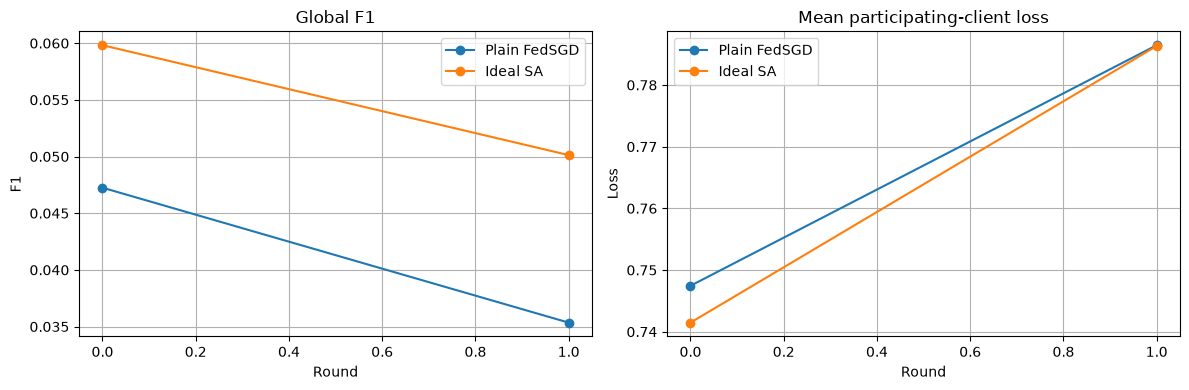

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, history in [("Plain FedSGD", plain_history), ("Ideal SA", sa_history)]:
    axes[0].plot(history["round"], [m["f1"] for m in history["global_metrics"]], marker="o", label=label)
axes[0].set(title="Global F1", xlabel="Round", ylabel="F1")
axes[0].grid(True)
axes[0].legend()

plain_losses = pd.DataFrame(plain_history["client_losses"])
sa_losses = pd.DataFrame(sa_history["client_losses"])
axes[1].plot(plain_losses.mean(axis=1), marker="o", label="Plain FedSGD")
axes[1].plot(sa_losses.mean(axis=1), marker="o", label="Ideal SA")
axes[1].set(title="Mean participating-client loss", xlabel="Round", ylabel="Loss")
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Optional baseline DLG attack

This cell only attacks a record exposed by plain FedSGD. It intentionally refuses to use ideal-SA state. Set `RUN_DLG = True` in the configuration cell when needed.

In [10]:
if not RUN_DLG:
    print("DLG skipped. Set RUN_DLG=True in the configuration cell to run it.")
else:
    record = leaked_records[0]
    x_hat = dlg_attack(
        record.theta_used,
        record.gradient,
        record.y_true,
        input_dim,
        num_iters=DLG_ITERATIONS,
    )
    reconstruction_scores = score_reconstruction(
        x_hat, record.x_true, X_train, rng
    )
    print("Mean DLG relative error:", float(reconstruction_scores["attack_err"].mean()))
    print("Mean random-baseline relative error:", float(reconstruction_scores["baseline_err"].mean()))


DLG skipped. Set RUN_DLG=True in the configuration cell to run it.


## Result checklist

A successful run currently means:

- all automated tests pass;
- ideal aggregation equals the expected tensor sum;
- plain FedSGD produces individual leak records;
- ideal SA produces no individual leak records;
- protected clients expose no `last_gradient` or `last_batch`;
- both modes produce utility metrics.

Future attack and defense milestones should be added as new scenarios after Scenario B, with their own assertions before plotting.